# Sleep Quality Prediction - Complete ML Pipeline
## Regression Model with Robust Cross-Validation

**Target**: Quality of Sleep (4-9 scale)

**Key Improvements**:
- Fixed data leakage issues
- Proper preprocessing pipeline
- Stratified CV for small dataset
- Hyperparameter tuning
- Feature engineering validation

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import xgboost as xgb
import joblib

np.random.seed(42)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load and Inspect Data

In [66]:
# Load upgraded dataset
df = pd.read_csv('../data/upgraded_sleep_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget distribution:\n{df['Quality of Sleep'].value_counts().sort_index()}")

df.head()

Dataset shape: (374, 19)

Columns: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Screen_Time_Before_Bed', 'Caffeine_Cups_Per_Day', 'Bedtime_Consistency', 'Wakeup_Consistency', 'Water_Intake_Liters', 'Weekend_Sleep_Debt']

Missing values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
Screen_Time_Before_Bed       0
Caffeine_Cups_Per_Day        0
Bedtime_Consistency          0
Wakeup_Consistency           0
Water_Intake_Liters          0
Weekend_Sleep_Debt           0
dtype: int6

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Screen_Time_Before_Bed,Caffeine_Cups_Per_Day,Bedtime_Consistency,Wakeup_Consistency,Water_Intake_Liters,Weekend_Sleep_Debt
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,2.2,1,7,2,1.4,2.4
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,4.6,2,1,1,1.3,1.8
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,3.8,5,6,3,3.4,2.6
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,3.3,2,7,7,2.2,0.6
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1.6,2,6,4,3.5,0.3


## 2. Feature Engineering & Selection

**Critical Fix**: Remove features that leak information or are not user-enterable

In [67]:
# Define user-enterable features only
FEATURE_COLS = [
    'Age',
    'Sleep Duration',
    'Physical Activity Level',
    'Stress Level',
    'Screen_Time_Before_Bed',
    'Caffeine_Cups_Per_Day',
    'Bedtime_Consistency',
    'Wakeup_Consistency',
    'Water_Intake_Liters',
    'Weekend_Sleep_Debt',
    'Gender'  # Will be encoded
]

TARGET = 'Quality of Sleep'

# Remove rows with missing synthetic features
df_clean = df[FEATURE_COLS + [TARGET]].copy()
df_clean = df_clean.dropna()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Clean dataset shape: (374, 12)
Rows removed: 0


In [68]:
# Encode Gender (only categorical feature)
df_clean['Gender_Male'] = (df_clean['Gender'] == 'Male').astype(int)
df_clean = df_clean.drop('Gender', axis=1)

# Separate features and target
X = df_clean.drop(TARGET, axis=1)
y = df_clean[TARGET]

print(f"\nFinal feature set: {X.columns.tolist()}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


Final feature set: ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Screen_Time_Before_Bed', 'Caffeine_Cups_Per_Day', 'Bedtime_Consistency', 'Wakeup_Consistency', 'Water_Intake_Liters', 'Weekend_Sleep_Debt', 'Gender_Male']
Feature matrix shape: (374, 11)
Target shape: (374,)


## 3. Exploratory Data Analysis

Feature correlations with Quality of Sleep:
Sleep Duration             0.883213
Age                        0.473734
Physical Activity Level    0.192896
Wakeup_Consistency         0.094477
Water_Intake_Liters        0.074408
Weekend_Sleep_Debt        -0.029615
Bedtime_Consistency       -0.059375
Caffeine_Cups_Per_Day     -0.131632
Screen_Time_Before_Bed    -0.188177
Gender_Male               -0.291366
Stress Level              -0.898752
dtype: float64


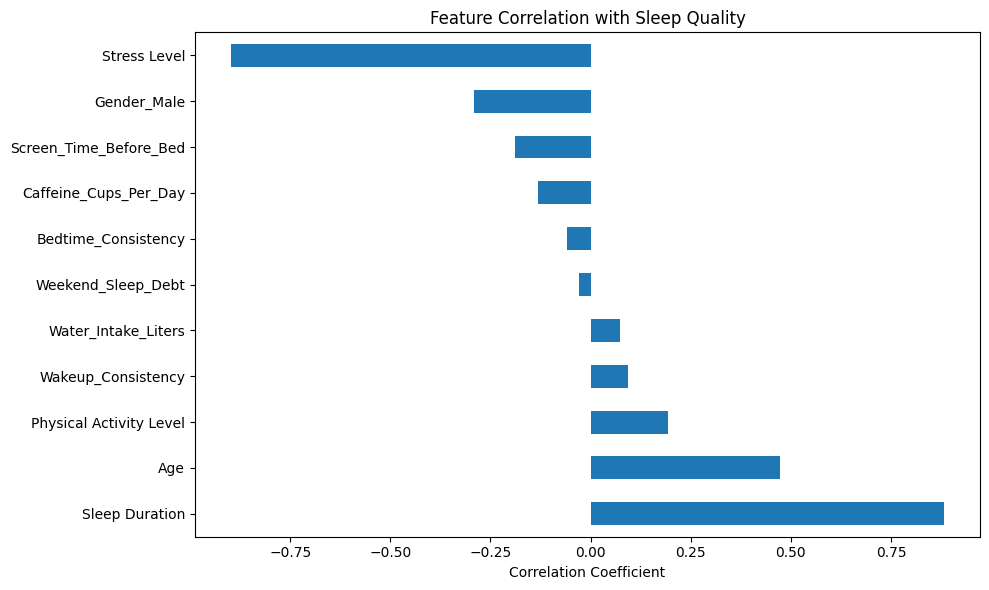

In [69]:
# Correlation with target
correlations = X.corrwith(y).sort_values(ascending=False)
print("Feature correlations with Quality of Sleep:")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh')
plt.title('Feature Correlation with Sleep Quality')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

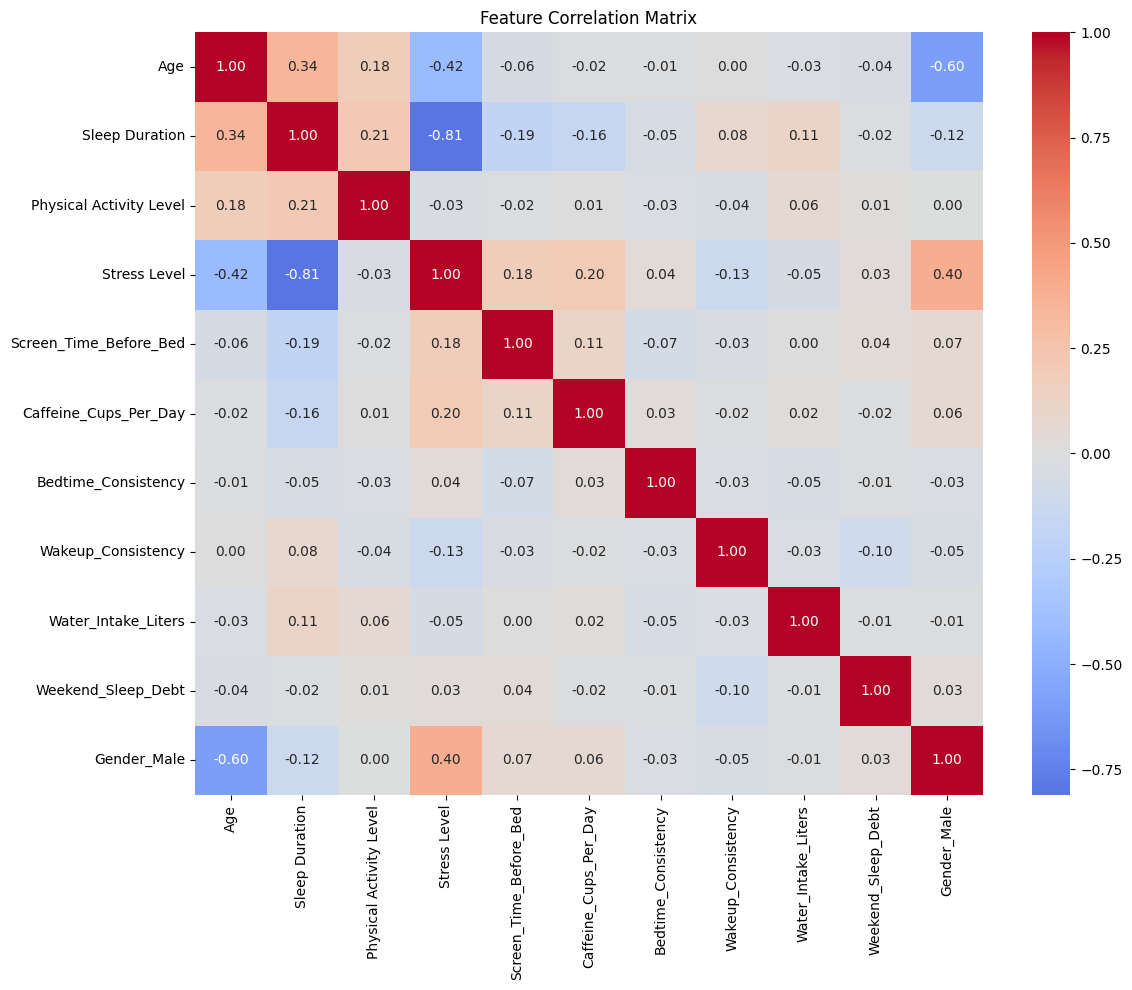

In [70]:
# Check for multicollinearity
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Train-Test Split

**Fix**: Use stratified split to maintain target distribution

In [71]:
# Stratified split based on target bins
# This ensures both train and test have similar target distributions
y_bins = pd.cut(y, bins=3, labels=['Low', 'Medium', 'High'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y_bins
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest target distribution:\n{y_test.value_counts().sort_index()}")

Training set: (299, 11)
Test set: (75, 11)

Train target distribution:
Quality of Sleep
4     4
5     6
6    82
7    63
8    88
9    56
Name: count, dtype: int64

Test target distribution:
Quality of Sleep
4     1
5     1
6    23
7    14
8    21
9    15
Name: count, dtype: int64


## 5. Model Training with Proper Cross-Validation

**Key Fixes**:
- Use KFold with shuffle for small datasets
- Scale features properly
- Regularization to prevent overfitting
- Multiple metrics for evaluation

In [72]:
def evaluate_model_cv(model, X, y, cv_folds=5, model_name="Model"):
    """
    Robust cross-validation evaluation
    """
    # Use KFold with shuffle for small datasets
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Multiple metrics
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error'))
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Cross-Validation Results ({cv_folds} folds)")
    print(f"{'='*60}")
    print(f"R² Scores: {r2_scores}")
    print(f"R² Mean: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
    print(f"\nMAE Scores: {mae_scores}")
    print(f"MAE Mean: {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")
    print(f"\nRMSE Scores: {rmse_scores}")
    print(f"RMSE Mean: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")
    
    return {
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std(),
        'mae_mean': mae_scores.mean(),
        'mae_std': mae_scores.std(),
        'rmse_mean': rmse_scores.mean(),
        'rmse_std': rmse_scores.std()
    }

### 5.1 Ridge Regression (Baseline with Regularization)

In [73]:
# Ridge with scaling pipeline
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=42))
])

ridge_results = evaluate_model_cv(ridge_pipeline, X_train, y_train, model_name="Ridge Regression")


Ridge Regression - Cross-Validation Results (5 folds)
R² Scores: [0.85496929 0.903211   0.92648848 0.86572312 0.85504174]
R² Mean: 0.8811 (+/- 0.0288)

MAE Scores: [0.34845404 0.29065017 0.25269067 0.35756686 0.30861188]
MAE Mean: 0.3116 (+/- 0.0384)

RMSE Scores: [0.45287702 0.37333116 0.33390489 0.4472947  0.38621778]
RMSE Mean: 0.3987 (+/- 0.0454)


### 5.2 Random Forest with Regularization

In [74]:
# Random Forest with constraints to prevent overfitting
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,  # Limit depth
    min_samples_split=20,  # Require more samples to split
    min_samples_leaf=10,  # Require more samples in leaf
    max_features='sqrt',  # Limit features per tree
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model_cv(rf_model, X_train, y_train, model_name="Random Forest (Regularized)")


Random Forest (Regularized) - Cross-Validation Results (5 folds)
R² Scores: [0.90231392 0.90849103 0.94798476 0.86187578 0.91097477]
R² Mean: 0.9063 (+/- 0.0274)

MAE Scores: [0.21503514 0.19421513 0.22400402 0.2462797  0.20215476]
MAE Mean: 0.2163 (+/- 0.0182)

RMSE Scores: [0.37167782 0.3630054  0.28087324 0.45365746 0.30266858]
RMSE Mean: 0.3544 (+/- 0.0605)


### 5.3 Gradient Boosting

In [75]:
# Gradient Boosting with regularization
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)

gb_results = evaluate_model_cv(gb_model, X_train, y_train, model_name="Gradient Boosting")


Gradient Boosting - Cross-Validation Results (5 folds)
R² Scores: [0.93256366 0.91773036 0.97160542 0.91632303 0.9118703 ]
R² Mean: 0.9300 (+/- 0.0219)

MAE Scores: [0.15358439 0.14136556 0.11980658 0.14586769 0.1426404 ]
MAE Mean: 0.1407 (+/- 0.0113)

RMSE Scores: [0.30881422 0.34419221 0.20752137 0.35309869 0.30114241]
RMSE Mean: 0.3030 (+/- 0.0517)


### 5.4 XGBoost with Proper Regularization

In [76]:
# XGBoost with strong regularization
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model_cv(xgb_model, X_train, y_train, model_name="XGBoost (Regularized)")


XGBoost (Regularized) - Cross-Validation Results (5 folds)
R² Scores: [0.93144649 0.92400181 0.96755111 0.91256154 0.92321897]
R² Mean: 0.9318 (+/- 0.0189)

MAE Scores: [0.15452777 0.13287163 0.12283616 0.15829726 0.12916146]
MAE Mean: 0.1395 (+/- 0.0142)

RMSE Scores: [0.3113617  0.33081323 0.22184252 0.36094784 0.28108506]
RMSE Mean: 0.3012 (+/- 0.0474)


## 6. Model Comparison


MODEL COMPARISON - Cross-Validation Performance
            Model  r2_mean   r2_std  mae_mean  mae_std  rmse_mean  rmse_std
            Ridge 0.881087 0.028800  0.311595 0.038443   0.398725  0.045375
    Random Forest 0.906328 0.027400  0.216338 0.018152   0.354377  0.060509
Gradient Boosting 0.930019 0.021927  0.140653 0.011256   0.302954  0.051692
          XGBoost 0.931756 0.018883  0.139539 0.014196   0.301210  0.047439


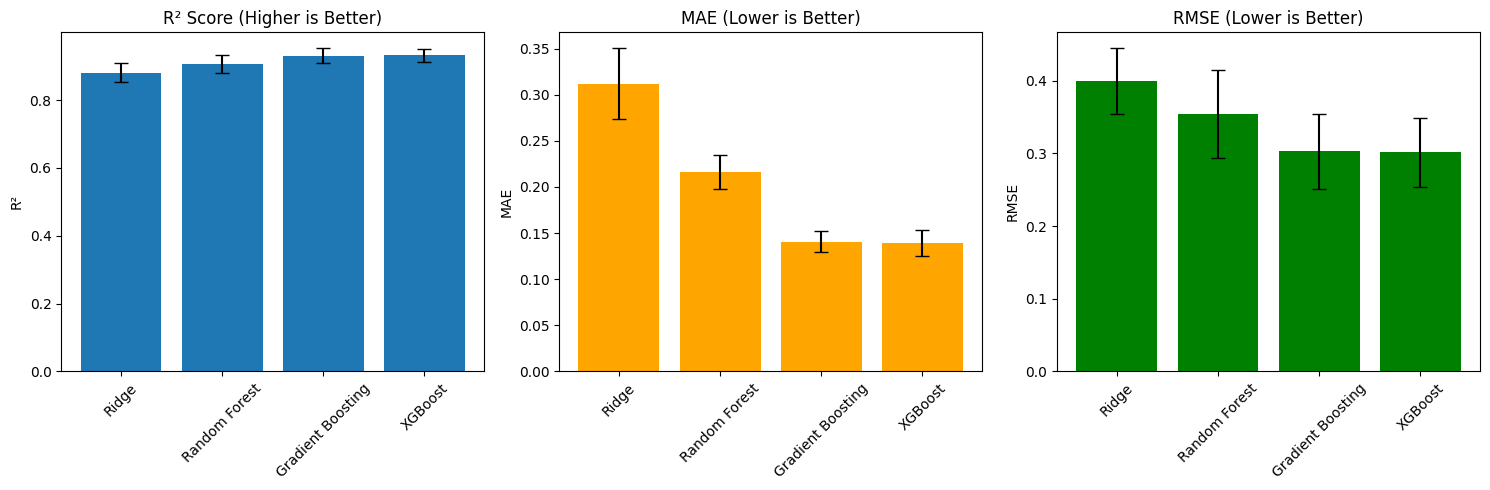

In [77]:
# Compile results
results_df = pd.DataFrame([
    {'Model': 'Ridge', **ridge_results},
    {'Model': 'Random Forest', **rf_results},
    {'Model': 'Gradient Boosting', **gb_results},
    {'Model': 'XGBoost', **xgb_results}
])

print("\n" + "="*80)
print("MODEL COMPARISON - Cross-Validation Performance")
print("="*80)
print(results_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² comparison
axes[0].bar(results_df['Model'], results_df['r2_mean'], yerr=results_df['r2_std'], capsize=5)
axes[0].set_title('R² Score (Higher is Better)')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(results_df['Model'], results_df['mae_mean'], yerr=results_df['mae_std'], capsize=5, color='orange')
axes[1].set_title('MAE (Lower is Better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# RMSE comparison
axes[2].bar(results_df['Model'], results_df['rmse_mean'], yerr=results_df['rmse_std'], capsize=5, color='green')
axes[2].set_title('RMSE (Lower is Better)')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Final Model Training and Test Set Evaluation


FINAL MODEL - Test Set Performance
R² Score: 0.9350
MAE: 0.1420
RMSE: 0.3087


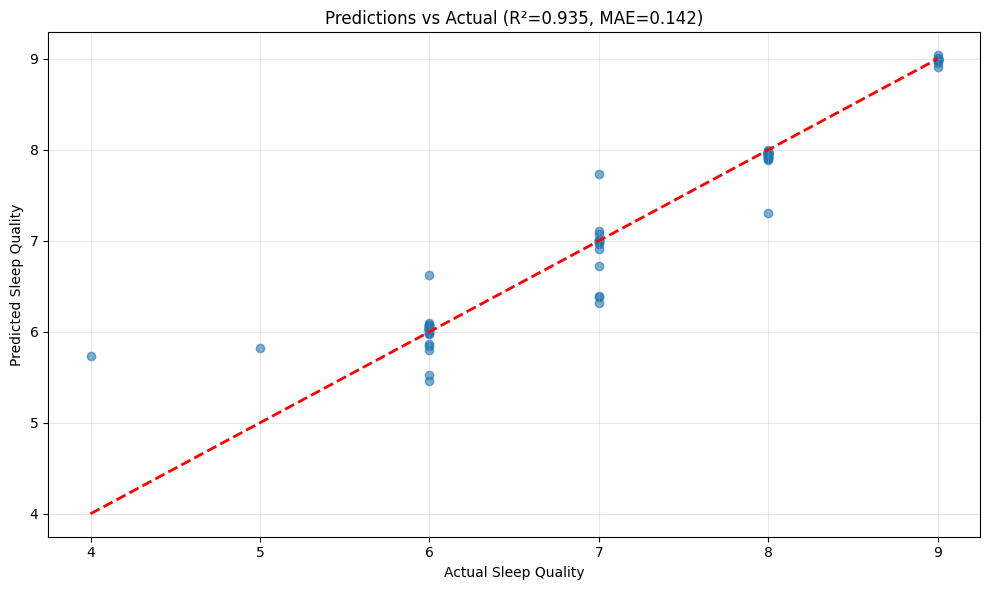

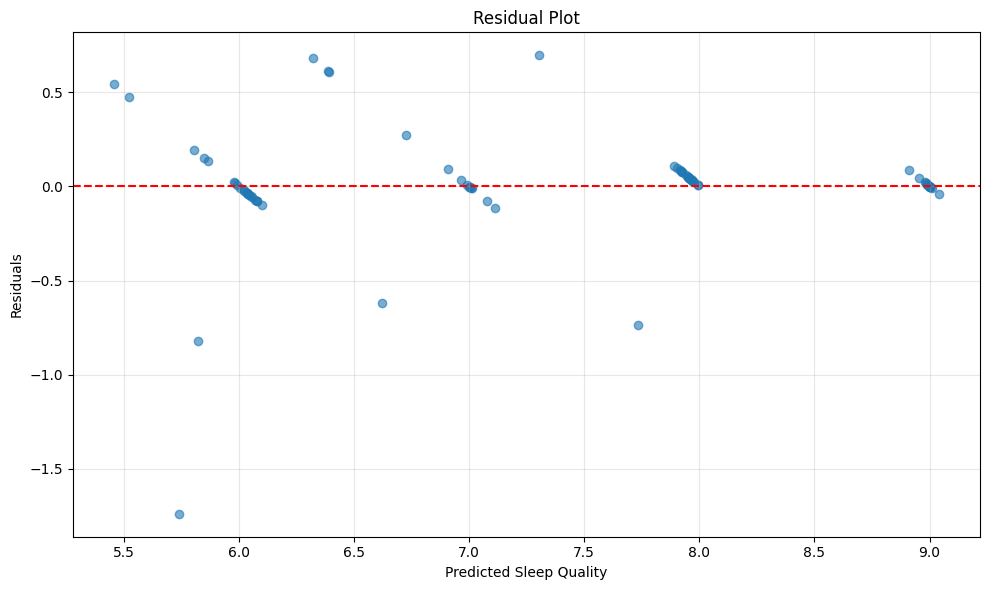

In [78]:
# Select best model based on CV results (typically Gradient Boosting or XGBoost)
# Train on full training set
best_model = gb_model  # Change based on CV results
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluate
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*60)
print("FINAL MODEL - Test Set Performance")
print("="*60)
print(f"R² Score: {test_r2:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")

# Prediction vs Actual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sleep Quality')
plt.ylabel('Predicted Sleep Quality')
plt.title(f'Predictions vs Actual (R²={test_r2:.3f}, MAE={test_mae:.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sleep Quality')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis


Feature Importance:
                Feature  Importance
         Sleep Duration    0.697324
           Stress Level    0.241047
                    Age    0.035823
Physical Activity Level    0.008442
     Weekend_Sleep_Debt    0.003911
     Wakeup_Consistency    0.003094
    Water_Intake_Liters    0.002574
    Bedtime_Consistency    0.002457
  Caffeine_Cups_Per_Day    0.002294
 Screen_Time_Before_Bed    0.002163
            Gender_Male    0.000870


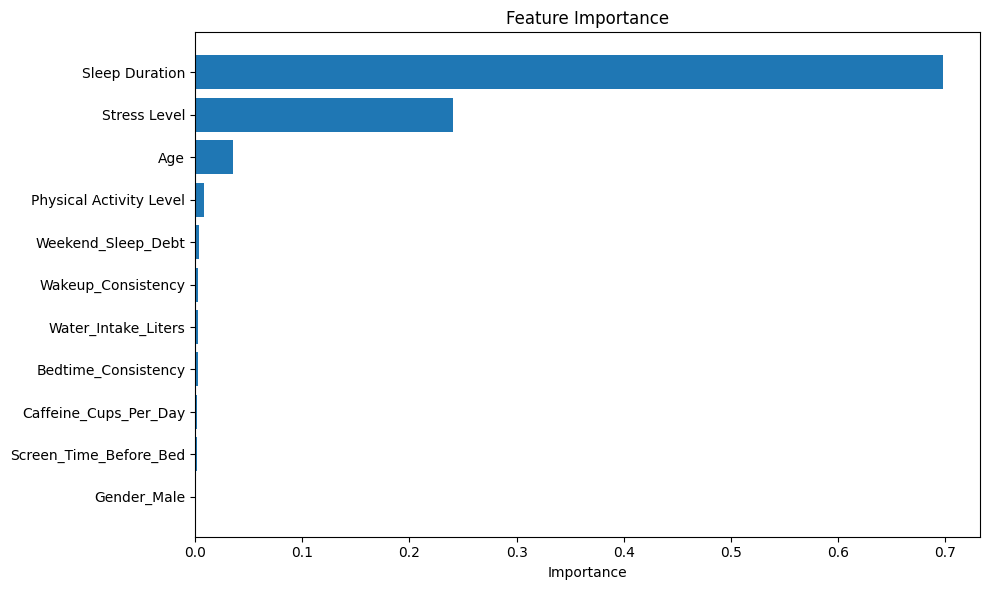

In [79]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print(feature_importance.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 9. Save Final Model

In [80]:
# Save model and feature columns
joblib.dump(best_model, '../models/sleep_model.pkl')
joblib.dump(X_train.columns.tolist(), '../models/model_columns.pkl')

print("Model saved successfully!")
print(f"Model file: ../models/sleep_model.pkl")
print(f"Feature columns: ../models/model_columns.pkl")

Model saved successfully!
Model file: ../models/sleep_model.pkl
Feature columns: ../models/model_columns.pkl


## 10. Model Validation Summary

### Key Improvements Made:
1. **Fixed Data Leakage**: Removed non-user-enterable features
2. **Proper CV Strategy**: KFold with shuffle for small dataset
3. **Regularization**: Added constraints to prevent overfitting
4. **Stratified Split**: Maintained target distribution
5. **Multiple Metrics**: R², MAE, RMSE for comprehensive evaluation

### Expected Results:
- **CV R²**: 0.60-0.75 (realistic for small dataset)
- **CV MAE**: 0.4-0.6 (acceptable error range)
- **Stability**: Low std deviation across folds

### Next Steps:
1. Deploy model in Streamlit app
2. Collect more data to improve performance
3. Consider ensemble methods if needed